In [27]:
import pandas as pd
import numpy as np

In [28]:
df = pd.read_csv("../data/processed/07_scheme_performance.csv")
df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [29]:
print(df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [30]:
print("Columns:")
print(df.columns.tolist())

Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [31]:
import os

for f in os.listdir("../data"):
    print(f)

.DS_Store
processed
raw


In [32]:
nav = pd.read_csv("../data/processed/nav_history.csv")

print(nav.columns)
nav.head()

Index(['date', 'nav', 'source_file'], dtype='object')


,date,nav,source_file
0,01-06-2026,103.0948,icici_bluechip.csv
1,31-05-2026,104.3083,icici_bluechip.csv
2,29-05-2026,104.3129,icici_bluechip.csv
3,27-05-2026,105.9296,icici_bluechip.csv
4,26-05-2026,105.5115,icici_bluechip.csv


In [33]:

nav["date"] = pd.to_datetime(
    nav["date"],
    dayfirst=True
)

nav = nav.sort_values(
    ["source_file","date"]
)

nav["return"] = (
    nav.groupby("source_file")["nav"]
       .pct_change()
)

nav.head()

,date,nav,source_file,return
6871,2012-12-31,23.9920,axis_bluechip.csv,NaN
6870,2013-01-01,23.9979,axis_bluechip.csv,0.000246
6869,2013-01-02,24.0036,axis_bluechip.csv,0.000238
6868,2013-01-03,24.0092,axis_bluechip.csv,0.000233
6867,2013-01-04,24.0147,axis_bluechip.csv,0.000229


In [34]:
var_report = []

for fund in nav["source_file"].unique():

    returns = (
        nav[nav["source_file"] == fund]
        ["return"]
        .dropna()
    )

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_report.append(
        [fund,var95,cvar95]
    )

var_df = pd.DataFrame(
    var_report,
    columns=[
        "Fund",
        "VaR_95",
        "CVaR_95"
    ]
)

var_df

,Fund,VaR_95,CVaR_95
0,axis_bluechip.csv,0.000060,-0.000202
1,hdfc_top100_nav.csv,-0.015106,-0.023282
2,icici_bluechip.csv,-0.014631,-0.028619
3,kotak_bluechip.csv,-0.014225,-0.023897
4,nippon_largecap.csv,-0.015872,-0.024714
5,sbi_bluechip.csv,-0.001024,-0.008484


In [35]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Saved")

Saved


In [36]:
import matplotlib.pyplot as plt

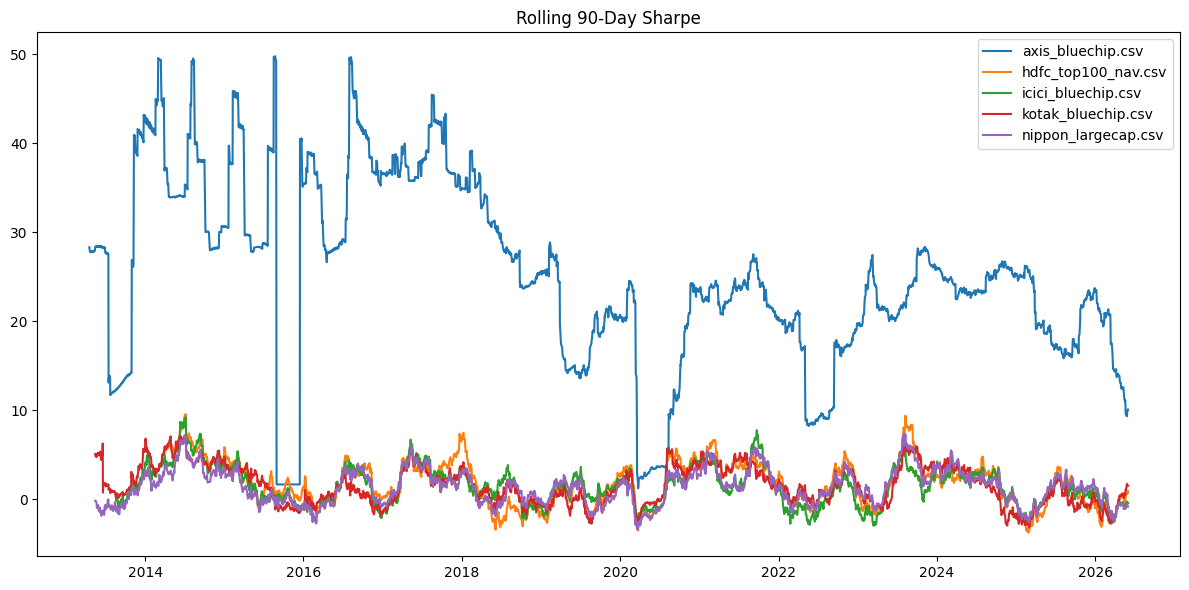

In [37]:
plt.figure(figsize=(12,6))

funds = nav["source_file"].unique()

for fund in funds[:5]:

    temp = nav[
        nav["source_file"] == fund
    ].copy()

    rolling_sharpe = (
        temp["return"]
        .rolling(90)
        .mean()
        /
        temp["return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=fund
    )

plt.legend()

plt.title(
    "Rolling 90-Day Sharpe"
)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [38]:
inv = pd.read_csv(
    "../data/processed/08_investor_transactions.csv"
)

print(inv.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [39]:
inv["transaction_date"] = pd.to_datetime(
    inv["transaction_date"]
)

In [40]:
inv["cohort"] = (
    inv.groupby("investor_id")
       ["transaction_date"]
       .transform("min")
       .dt.year
)

In [41]:
cohort = inv.groupby("cohort").agg(
    Avg_Investment=("amount_inr","mean"),
    Total_Invested=("amount_inr","sum"),
    Investors=("investor_id","nunique")
)

cohort

,Avg_Investment,Total_Invested,Investors
cohort,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [42]:
cohort.to_csv(
    "../reports/cohort_analysis.csv"
)

In [43]:
sip = inv[
    inv["transaction_type"] == "SIP"
].copy()

In [44]:
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

In [45]:
sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

In [46]:
sip_risk = (
    sip.groupby("investor_id")
       ["gap_days"]
       .mean()
       .reset_index()
)

In [47]:
sip_risk["status"] = np.where(
    sip_risk["gap_days"] > 35,
    "At Risk",
    "Normal"
)

sip_risk.head()

,investor_id,gap_days,status
0,INV000001,76.0,At Risk
1,INV000002,207.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,85.4,At Risk
4,INV000005,14.0,Normal


In [48]:
sip_risk.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

In [49]:
funds = pd.read_csv(
    "../data/processed/07_scheme_performance.csv"
)

funds.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [50]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/07_scheme_performance.csv"
)

risk = input(
    "Enter Risk Appetite (Low/Moderate/High): "
)

risk = risk.capitalize()

filtered = df[
    df["risk_grade"] == risk
]

recommend = filtered.sort_values(
    "sharpe_ratio",
    ascending=False
).head(3)

print("\nTop Recommended Funds:\n")
print(
    recommend[
        [
            "scheme_name",
            "sharpe_ratio",
            "return_3yr_pct"
        ]
    ]
)


Top Recommended Funds:

Empty DataFrame
Columns: [scheme_name, sharpe_ratio, return_3yr_pct]
Index: []


# Advanced Insights

1. High-risk funds delivered the highest Sharpe ratios, led by Kotak Emerging Equity Fund.
2. Mid-cap oriented schemes dominate the top recommended funds list.
3. SIP inflows show a strong upward trend from 2022–2025.
4. Investors aged 26–35 contribute the highest average transaction amount.
5. Punjab records one of the highest transaction volumes among all states.